In [295]:
import torch
import torch.nn as nn
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [296]:
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)

In [297]:
data = pd.read_csv("train_dataset.csv")
data

,YearBuilt,Size(sqf),Floor,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,N_FacilitiesInApt,...,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,SubwayStation_Myung-duk,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby,SalePrice,PriceCategoryNum,PriceCategory
0,2006.0,814.0,3.0,111.0,184.0,7.5,12.5,3.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,141592.0,1.0,average
1,1985.0,587.0,8.0,80.0,76.0,2.5,7.5,2.0,2.0,3.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,51327.0,0.0,cheap
2,1985.0,587.0,6.0,80.0,76.0,2.5,7.5,2.0,2.0,3.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,48672.0,0.0,cheap
3,2006.0,2056.0,8.0,249.0,536.0,2.5,2.5,5.0,11.0,5.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,380530.0,2.0,expensive
4,1992.0,644.0,2.0,142.0,79.0,7.5,17.5,4.0,8.0,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,78318.0,0.0,cheap
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,2007.0,1928.0,24.0,0.0,1270.0,2.5,2.5,14.0,16.0,10.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,570796.0,2.0,expensive
4120,2015.0,644.0,22.0,102.0,400.0,2.5,7.5,5.0,10.0,7.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,307079.0,1.0,average
4121,2007.0,868.0,20.0,0.0,1270.0,2.5,2.5,14.0,16.0,10.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,357522.0,2.0,expensive
4122,1978.0,1327.0,1.0,87.0,0.0,2.5,2.5,1.0,4.0,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,312389.0,1.0,average


In [298]:
X = data.loc[:, :"SubwayStation_no_subway_nearby"]
y = data[["PriceCategoryNum", "SalePrice"]]

In [299]:
features_scaler = joblib.load("features_scaler.pkl")
sale_price_scaler = joblib.load("sale_price_scaler.pkl")

In [300]:
features_to_scale = features_scaler.feature_names_in_
features_to_scale

array(['YearBuilt', 'Size(sqf)', 'Floor', 'N_Parkinglot(Ground)',
       'N_Parkinglot(Basement)', 'TimeToBusStop', 'TimeToSubway',
       'N_manager', 'N_elevators', 'N_FacilitiesInApt',
       'N_FacilitiesNearBy(Total)', 'N_SchoolNearBy(Total)'], dtype=object)

In [301]:
X[features_to_scale] = features_scaler.transform(X[features_to_scale])
y.loc[:, "SalePrice"] = sale_price_scaler.transform(y[["SalePrice"]])


/var/folders/rh/8hh2vd4j4xzcvyl1kj3kzf600000gn/T/ipykernel_96724/1561421065.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[[-0.75800464]
 [-1.60705699]
 [-1.6320305 ]
 ...
 [ 1.27308021]
 [ 0.84854933]
 [ 1.61436605]]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  y.loc[:, "SalePrice"] = sale_price_scaler.transform(y[["SalePrice"]])


In [302]:
X.describe()

,YearBuilt,Size(sqf),Floor,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,N_FacilitiesInApt,...,AptManageType_management_in_trust,AptManageType_self_management,SubwayStation_Bangoge,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,SubwayStation_Myung-duk,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby
count,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,...,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000
mean,0.003935,0.038782,-0.014121,-0.045732,0.017060,0.014462,-0.026680,0.003788,-0.037565,0.021263,...,0.938167,0.061833,0.124151,0.128758,0.020611,0.015034,0.272793,0.258244,0.113482,0.066925
std,0.982936,1.019057,1.014682,0.955069,0.996517,1.006379,0.999059,1.056169,0.963839,1.019909,...,0.240882,0.240882,0.329794,0.334973,0.142096,0.121703,0.445450,0.437722,0.317220,0.249923
min,-2.796905,-2.147367,-1.485642,-0.900324,-1.381495,-0.533527,-0.797327,-1.736681,-1.418405,-2.077521,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-1.114917,-0.798512,-0.816444,-0.851564,-0.932284,-0.533527,-0.797327,-0.426524,-0.793917,-0.772361,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.342807,-0.093610,-0.147246,-0.457046,-0.072923,-0.533527,-0.156054,-0.098985,-0.044531,-0.337308,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.454940,0.568893,0.655791,0.203439,0.566715,-0.533527,0.485219,0.556094,0.579958,0.532799,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,1.352000,3.687954,4.135620,2.260250,1.843549,3.923885,3.370946,2.521329,1.953832,1.837958,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [303]:
y.describe()

,PriceCategoryNum,SalePrice
count,4124.000000,4.124000e+03
mean,1.001940,5.513426e-17
std,0.523979,1.000121e+00
min,0.000000,-1.769380e+00
25%,1.000000,-7.282810e-01
50%,1.000000,-1.184194e-01
75%,1.000000,6.527213e-01
max,2.000000,3.420689e+00


In [304]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_SEED
)

X_train.shape, y_train.shape

((3505, 27), (3505, 2))

In [305]:
def create_dataset(X: pd.DataFrame, y: pd.DataFrame) -> torch.utils.data.Dataset:
    X_tensor = torch.Tensor(X.to_numpy())
    y_tensor = torch.Tensor(y.to_numpy()).squeeze()
    return torch.utils.data.TensorDataset(X_tensor, y_tensor)


train_dataset = create_dataset(X_train, y_train["PriceCategoryNum"])
val_dataset = create_dataset(X_val, y_val["PriceCategoryNum"])


In [306]:
from sklearn.utils.class_weight import compute_class_weight

y_train_numpy = np.squeeze(y_train.to_numpy()[:, 0])

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_numpy), y=list(y_train_numpy)
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)


In [307]:
from torchmetrics import Accuracy
import lightning as L


class LitPriceClassifier(L.LightningModule):
    def __init__(
        self,
        classifier: nn.Module,
    ):
        super().__init__()

        self.classifier = classifier
        self.criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

        self.metric_train_acc = Accuracy(task="multiclass", num_classes=3)
        self.metric_val_acc = Accuracy(task="multiclass", num_classes=3)
        self.metric_test_acc = Accuracy(task="multiclass", num_classes=3)

    def training_step(self, batch, batch_idx):
        X, y = batch
        y = y.type(torch.long)
        logits = self.classifier(X)
        loss = self.criterion(logits, y)
        self.log("train/loss", loss, prog_bar=True)

        preds = torch.argmax(logits, dim=1)
        self.metric_train_acc(preds, y)
        self.log(
            "train/accuracy",
            self.metric_train_acc,
            on_step=True,
            on_epoch=False,
            prog_bar=True,
        )
        return loss

    def validation_step(self, batch, batch_idx):
        x, target = batch
        target = target.type(torch.long)
        logits = self.classifier(x)
        loss = self.criterion(logits, target)
        self.log("val/loss", loss, prog_bar=True)

        _, preds = torch.max(logits, dim=1)
        self.metric_val_acc(preds, target)
        self.log(
            "val/accuracy",
            self.metric_val_acc,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
        )

    def test_step(self, batch, batch_idx):
        x, target = batch
        logits = self.classifier(x)

        _, preds = torch.max(logits, dim=1)
        self.metric_test_acc(preds, target)
        self.log(
            "test/accuracy",
            self.metric_test_acc,
        )

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            params=self.classifier.parameters(),
            lr=1e-3,
        )
        return {"optimizer": optimizer}


In [308]:
class PriceClassifier(nn.Module):
    def __init__(self, in_features: int, hidden_units: int, out_features: int):
        super().__init__()

        self.stack = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=hidden_units),
            nn.BatchNorm1d(hidden_units),
            nn.LeakyReLU(),
            nn.Dropout(0.3),
            nn.Linear(in_features=hidden_units, out_features=out_features),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.stack(x)

In [309]:
sample = train_dataset[0]
sample

(tensor([ 0.2307, -0.5362, -1.3518, -0.6033,  0.5667, -0.5335, -0.1561, -0.0990,
         -1.4184,  0.5328,  0.8966,  0.9309,  0.0000,  1.0000,  0.0000,  0.0000,
          1.0000,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000]),
 tensor(1.))

In [310]:
import torch.utils.data.dataloader


in_features = sample[0].shape[-1]
hidden_units = 128
out_features = 3

classifier = PriceClassifier(in_features, hidden_units, out_features)
model = LitPriceClassifier(classifier)

batch_size = 64

train_data_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size, shuffle=True, drop_last=True
)
val_data_loader = torch.utils.data.DataLoader(val_dataset, batch_size)

In [311]:
trainer = L.Trainer(max_epochs=20, accelerator="cpu")
trainer.fit(model, train_dataloaders=train_data_loader, val_dataloaders=val_data_loader)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/daniel/Studia/Semestr_6/SSNE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name             | Type               | Params | Mode 
----------------------------------------------------------------
0 | classifier       | PriceClassifier    | 4.2 K  | train
1 | criterion        | CrossEntropyLoss   | 0      | train
2 | metric_train_acc | MulticlassAccuracy | 0      | train
3 | metric_val_acc   | MulticlassAccuracy | 0      | train
4 | metric_test_acc  | MulticlassAccuracy | 0      | train
----------------------------------------------------------------
4.2 K     Trainable params
0         Non-trainable params
4.2 K     Total

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/daniel/Studia/Semestr_6/SSNE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/daniel/Studia/Semestr_6/SSNE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


In [312]:
preds_l = []
targets_l = []

device = torch.device("cpu")

classifier.eval()

for X_batch, target in val_data_loader:
    X_batch, target = X_batch.to(device), target.to(device)

    with torch.inference_mode():
        logits = classifier(X_batch)
        _, preds = torch.max(logits, dim=-1)
        preds_l.extend(preds.cpu().numpy())
        targets_l.extend(target.cpu().numpy())

preds = np.array(preds_l)
targets = np.array(targets_l)

print(f"{preds.shape=}")
print(f"{targets.shape=}")

preds.shape=(619,)
targets.shape=(619,)


In [313]:
from sklearn.metrics import classification_report

labels = ["cheap", "average", "expensive"]

report = classification_report(targets, preds, target_names=labels)
print(report)

              precision    recall  f1-score   support

       cheap       0.61      1.00      0.75        95
     average       0.98      0.73      0.84       436
   expensive       0.59      0.91      0.72        88

    accuracy                           0.80       619
   macro avg       0.72      0.88      0.77       619
weighted avg       0.86      0.80      0.81       619



In [314]:
from sklearn.metrics import balanced_accuracy_score

bal_acc = balanced_accuracy_score(targets, preds)
bal_acc

np.float64(0.8802474284125661)

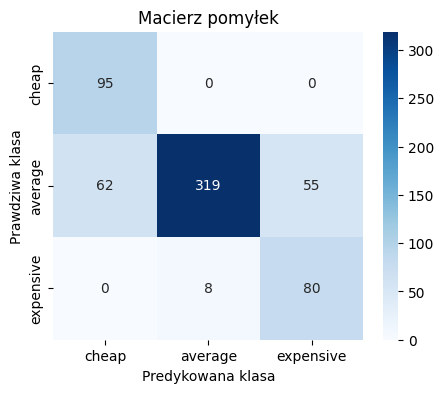

In [315]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(targets, preds)

plt.figure(figsize=(5, 4))
fig = sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels
)
plt.title("Macierz pomyłek")
plt.xlabel("Predykowana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()